## Simulation

Small notebook to run the simulation and see what is happening

#### TFIM Local magnetization

In [20]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

outputs = os.path.join(os.getcwd(), "OUT")
cor = cm.Blues(np.linspace(0.4, 1, 21))
values = []
h_indices = []
plt.figure(figsize=(12, 8))

for index, h_value in enumerate(sorted(os.listdir(outputs))):
    result = os.path.join(outputs, h_value)

    arr = np.loadtxt(os.path.join(result, "Z.txt"))
    arr = arr.T
    values.append(min(arr[1]))
    h_indices.append(h_value.split("_")[1])
    plt.scatter(arr[0], arr[1], color=cor[index], label=f"h = {h_value.split("_")[1]}")


plt.legend(loc="upper right")
plt.grid()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/home/silvanita/Desktop/OUT'

<Figure size 1200x800 with 0 Axes>

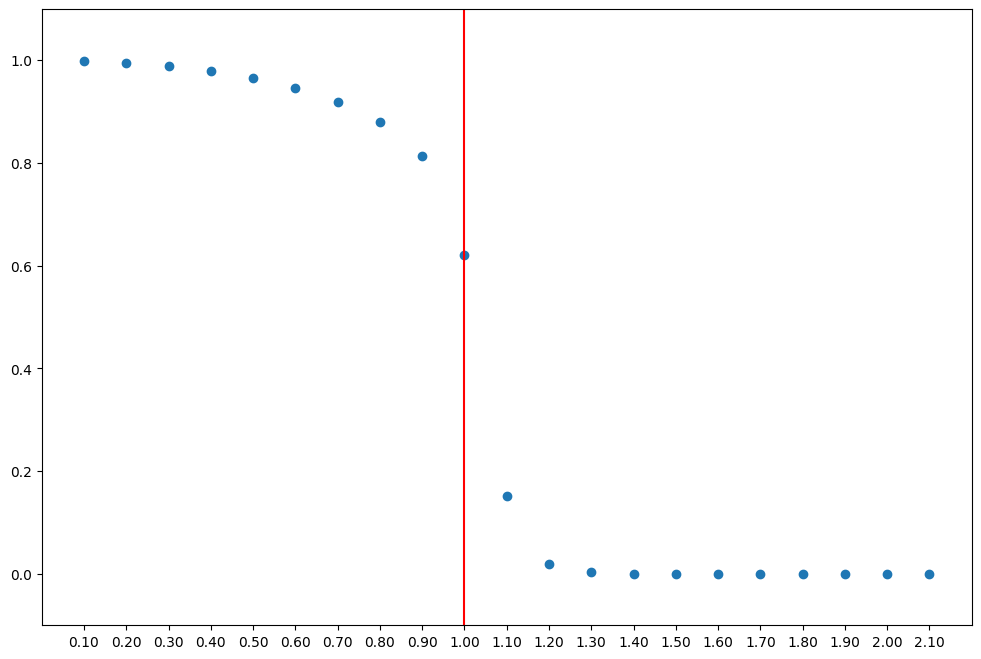

In [ ]:
plt.figure(figsize=(12, 8))
plt.scatter(h_indices, values, label="L = 50")
plt.ylim((min(values)-.1, max(values)+.1))
plt.vlines(9, min(values)-.1, max(values)+.1, colors='red')

#### Data processing of values - Open BC

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt

# change home directory to OUT
home = os.getcwd()
os.chdir("..")
dir = os.path.join(os.getcwd(), "OUT/First_Run")

# extract data
h_values = np.arange(0, 2.1, 0.2)
k_values = np.arange(-2, 2.1, 0.2)
results = np.zeros((len(h_values), len(k_values)))
results2 = np.zeros((len(h_values), len(k_values)))
woops = []
for ind, file in enumerate(os.listdir(dir)):
    name = file.split("_")
    
    h = float(name[1])
    k = float(name[2])
    h_idx = np.where(np.isclose(h_values, h, atol=1e-8))[0][0]
    k_idx = np.where(np.isclose(k_values, k, atol=1e-8))[0][0]

    loc = os.path.join(dir, file)
    magnetization = np.loadtxt(os.path.join(loc, "Z.txt")).T
    results[h_idx][k_idx] = min(magnetization[1])
    entropy = np.loadtxt(os.path.join(loc, "S.txt")).T
    results2[h_idx][k_idx] = max(entropy[2])

    # check convergence
    E = np.loadtxt(os.path.join(loc, "E_sweep.txt")).T

    if not np.isclose(E[-1], E.min(), atol=1e-8):
        woops.append([h, k])

# reset the home directory after each run
os.chdir(home)

##### Checking for convergence

In [9]:
# all parameter points that dont converge well
woops = np.array(woops)
if woops.shape == (0,):
    print("Everything converged!")
else:
    plt.scatter(woops[1], woops[0])

Everything converged!


##### Magnetization Plotting

##### Plotting via imshow

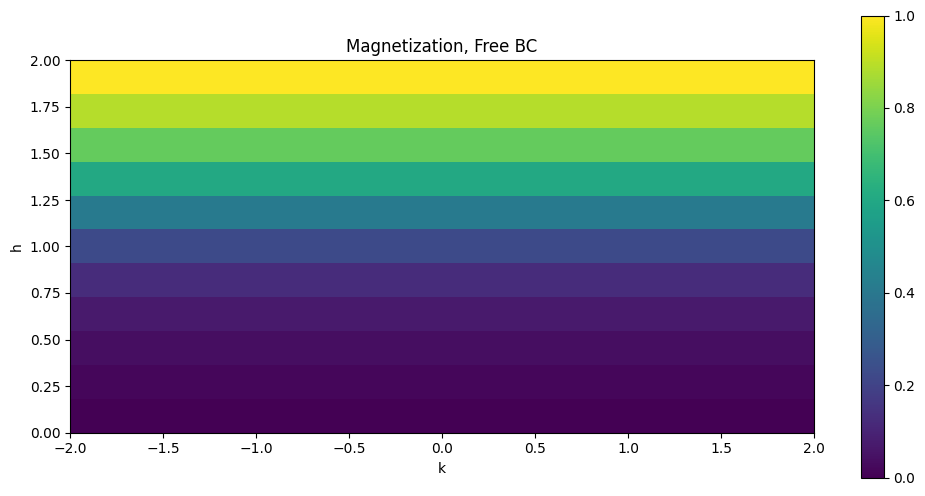

In [35]:
from matplotlib import cm
fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(results, interpolation='none', extent=[-2, 2, 0, 2])
fig.colorbar(cm.ScalarMappable(), ax=ax)
ax.set_title("Magnetization, Free BC")
ax.set_xlabel("k")
ax.set_ylabel('h')
plt.show()

# plt.imshow(results)

##### Entanglement Entropy

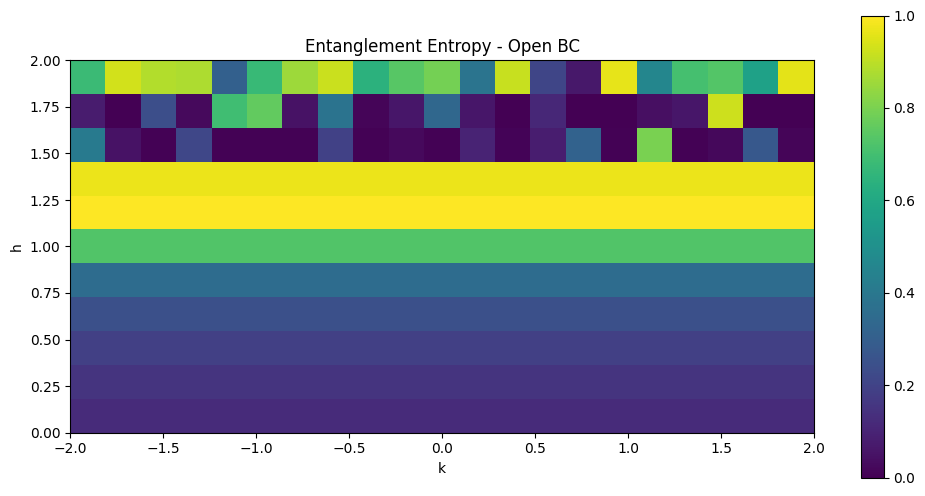

In [36]:
from matplotlib import cm
fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(results2, interpolation='none', extent=[-2, 2, 0, 2])
fig.colorbar(cm.ScalarMappable(), ax=ax)
ax.set_xlabel("k")
ax.set_ylabel('h')
ax.set_title("Entanglement Entropy - Open BC")
plt.show()


#### Data processing - Fixed X Polarization

In [41]:
import os
import numpy as np
import matplotlib.pyplot as plt

# change home directory to OUT
home = os.getcwd()
os.chdir("..")
dir = os.path.join(os.getcwd(), "OUT/new")

# extract data
h_values = np.arange(0, 1.1, 0.2)
k_values = np.arange(-2, 2.1, 0.2)
results = np.zeros((len(h_values), len(k_values)))
results2 = np.zeros((len(h_values), len(k_values)))
woops = []
for ind, file in enumerate(os.listdir(dir)):
    name = file.split("_")
    
    h = float(name[1])
    k = float(name[2])
    h_idx = np.where(np.isclose(h_values, h, atol=1e-8))[0][0]
    k_idx = np.where(np.isclose(k_values, k, atol=1e-8))[0][0]

    loc = os.path.join(dir, file)
    magnetization = np.loadtxt(os.path.join(loc, "Z.txt")).T
    results[h_idx][k_idx] = min(magnetization[1])
    entropy = np.loadtxt(os.path.join(loc, "S.txt")).T
    results2[h_idx][k_idx] = max(entropy[2])

    # check convergence
    E = np.loadtxt(os.path.join(loc, "E_sweep.txt")).T

    if not np.isclose(E[-1], E.min(), atol=1e-8):
        woops.append([h, k])

# reset the home directory after each run
os.chdir(home)

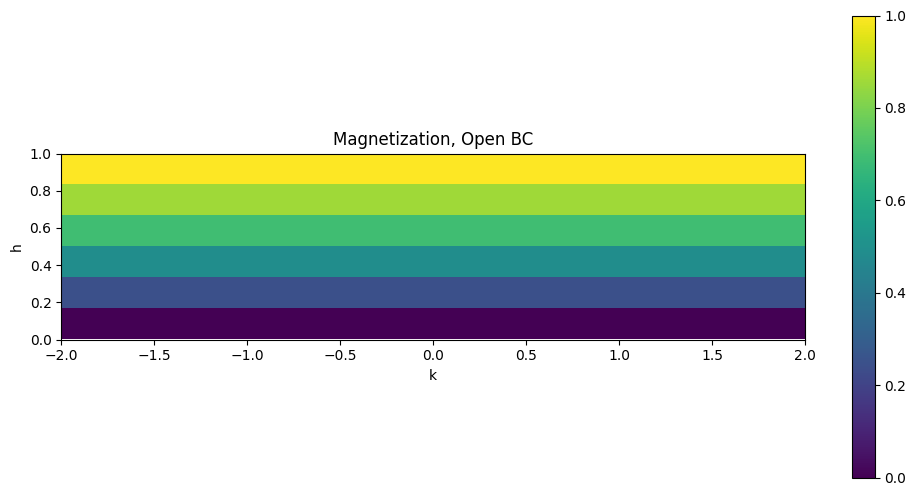

In [42]:
from matplotlib import cm
fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(results, interpolation='none', extent=[-2, 2, 0, 1])
fig.colorbar(cm.ScalarMappable(), ax=ax)
ax.set_title("Magnetization, Open BC")
ax.set_xlabel("k")
ax.set_ylabel('h')
plt.show()

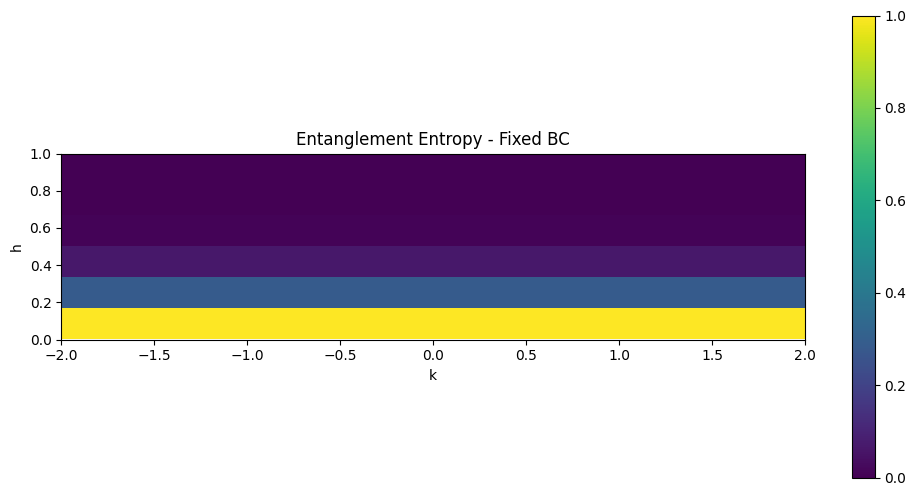

In [43]:
from matplotlib import cm
fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(results2, interpolation='none', extent=[-2, 2, 0, 1])
fig.colorbar(cm.ScalarMappable(), ax=ax)
ax.set_xlabel("k")
ax.set_ylabel('h')
ax.set_title("Entanglement Entropy - Fixed BC")
plt.show()
